E-commerce

##Planning

Links

Dataset - https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews$0



Train model

Dummy interface (like amazon)

Model generates useful info on product based off reviews

##Download e-commerce dataset as 'df'

In [95]:
import kagglehub
import pandas
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Womens Clothing E-Commerce Reviews.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nicapotato/womens-ecommerce-clothing-reviews",
  file_path,
  pandas_kwargs={'encoding': 'latin1'}
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_copy = df.copy()
print("First 5 records of the DataFrame:")
display(df_copy.head())


Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.
First 5 records of the DataFrame:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Data Cleaning

In [96]:
print("Shape:", df.shape)
df.info()


Shape: (23486, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [97]:
display(df_copy['Age'].describe())

,Age
count,23486.000000
mean,43.198544
std,12.279544
min,18.000000
25%,34.000000
50%,41.000000
75%,52.000000
max,99.000000


Our age range is 18-99, so we can group ages within this range later.

In [98]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing > 0]
missing_div = df_copy[df_copy['Division Name'].isna()].index
missing_dep = df_copy[df_copy['Department Name'].isna()].index
missing_cl = df_copy[df_copy['Class Name'].isna()].index

print("Division == Department:", missing_div.equals(missing_dep))
print("Department == Class:", missing_dep.equals(missing_cl))

df_copy.loc[missing_div, ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']]

Division == Department: True
Department == Class: True


,Clothing ID,Division Name,Department Name,Class Name
9444,72,NaN,NaN,NaN
13767,492,NaN,NaN,NaN
13768,492,NaN,NaN,NaN
13787,492,NaN,NaN,NaN
16216,152,NaN,NaN,NaN
16221,152,NaN,NaN,NaN
16223,152,NaN,NaN,NaN
18626,184,NaN,NaN,NaN
18671,184,NaN,NaN,NaN
20088,772,NaN,NaN,NaN


In [99]:
for clothing_id in df_copy.loc[missing_div, 'Clothing ID'].unique():
    same_item = df_copy[df_copy['Clothing ID'] == clothing_id]
    has_info = same_item['Division Name'].notna().any()
    total = len(same_item)
    filled = same_item['Division Name'].notna().sum()

    print(f"Clothing ID {clothing_id}: {filled}/{total} rows have category info — {'✓ can impute' if has_info else '✗ drop'}")

Clothing ID 72: 0/1 rows have category info — ✗ drop
Clothing ID 492: 0/3 rows have category info — ✗ drop
Clothing ID 152: 0/3 rows have category info — ✗ drop
Clothing ID 184: 0/2 rows have category info — ✗ drop
Clothing ID 772: 0/1 rows have category info — ✗ drop
Clothing ID 665: 0/1 rows have category info — ✗ drop
Clothing ID 136: 0/3 rows have category info — ✗ drop


In [100]:
df_copy = df_copy.drop(index=missing_div)

In [101]:
print(f"shape after drop: {df_copy.shape}")
print(df_copy[['Division Name', 'Department Name', 'Class Name']].isna().sum())

shape after drop: (23472, 11)
Division Name      0
Department Name    0
Class Name         0
dtype: int64


In [102]:
missing[missing > 0]

,0
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14


In [103]:
df_copy['Title']= df_copy['Title'].fillna('No Title')
df_copy['Review Text'] = df_copy['Review Text'].fillna('No Review')
print(df_copy[['Title', 'Review Text']].isna().sum())


Title          0
Review Text    0
dtype: int64


In [104]:
missing = df_copy.isna().sum().sort_values(ascending=False)
missing[missing>0]

,0


### Removing Low-Volume Products
To ensure statistical significance in our ratings and recommendation logic, we will remove any `Clothing ID` that has fewer than 3 reviews total.

In [105]:
# 1. Count reviews per product
product_counts = df_copy['Clothing ID'].value_counts()

# 2. Identify IDs with < 3 reviews
low_volume_ids = product_counts[product_counts < 3].index
print(f"Number of low-volume products found: {len(low_volume_ids)}")

# 3. Filter the datasets
df_copy = df_copy[~df_copy['Clothing ID'].isin(low_volume_ids)]

# FIX: Initialize df_rating as a copy of the filtered df_copy
# This ensures the variable exists for subsequent cells
df_rating = df_copy.copy()

print(f"Remaining records in df_copy: {len(df_copy)}")
print(f"Remaining records in df_rating: {len(df_rating)}")

Number of low-volume products found: 674
Remaining records in df_copy: 22612
Remaining records in df_rating: 22612


##Visualizations



#####Raw Data

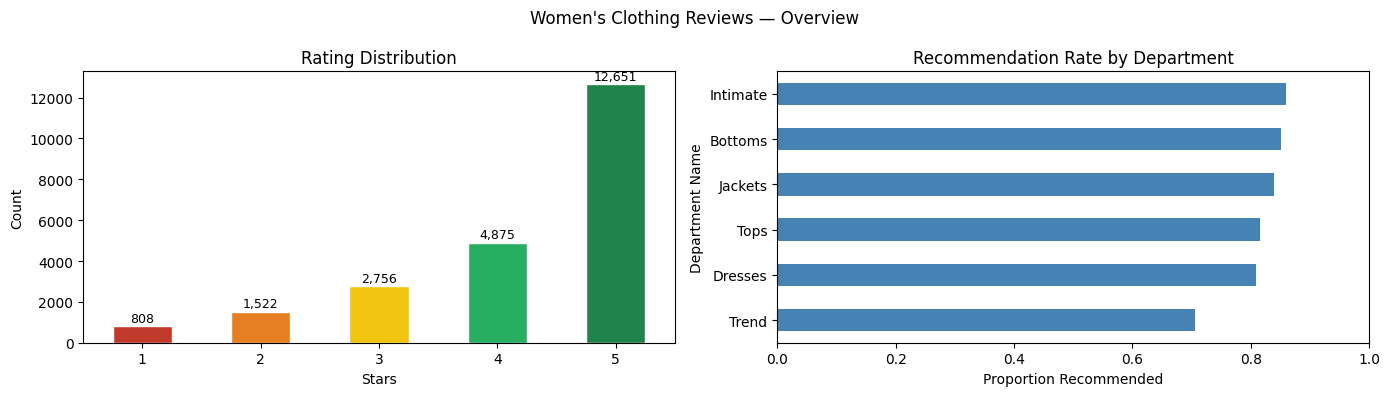

In [106]:
# ── Visualizations: Raw Data ──────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Women's Clothing Reviews — Overview")

# Plot 1: Rating distribution
df_copy['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#c0392b','#e67e22','#f1c40f','#27ae60','#1e8449'],
    edgecolor='white'
)
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Stars")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=9
    )

# Plot 2: Recommendation rate by department
dept_rec = (df_copy
    .groupby('Department Name')['Recommended IND']
    .mean()
    .sort_values()
)
dept_rec.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Recommendation Rate by Department")
axes[1].set_xlabel("Proportion Recommended")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()













































##Preprocessing


In [107]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# drop rows with no review text
df_model = df_copy.dropna(subset=['Review Text']).copy()

# drop 3-star rows
df_model = df_model[df_model['Rating'] != 3]

# create binary label
df_model['label'] = (df_model['Rating'] >= 4).astype(int)

print(f"Total rows: {len(df_model):,}")
print(f"Positive (4-5*)): {(df_model['label'] == 1).sum():,}")
print(f"Negative (1-2*): {(df_model['label'] == 0).sum():,}")

# apply preprocessing — takes ~30 seconds
df_model['clean_review'] = df_model['Review Text'].apply(preprocess_text)

# sanity check
print("\nBEFORE:", df_model['Review Text'].iloc[0][:100])
print("AFTER: ", df_model['clean_review'].iloc[0][:100])

Total rows: 19,856
Positive (4-5*)): 17,526
Negative (1-2*): 2,330

BEFORE: Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never
AFTER:  love dress sooo pretty happened find store glad never would ordered online petite bought petite love


#####Word Clouds

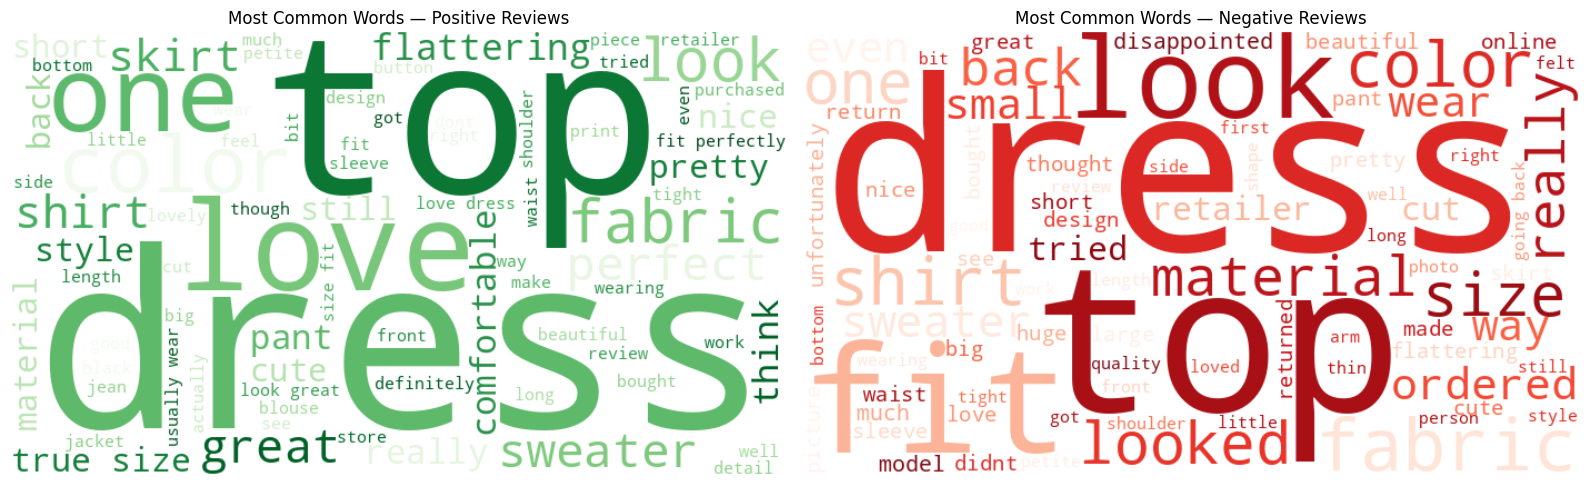

In [108]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df_model[df_model['label'] == 1]['clean_review'])
negative_text = " ".join(df_model[df_model['label'] == 0]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(
    WordCloud(width=700, height=400, colormap='Greens',
              max_words=80, background_color='white')
    .generate(positive_text),
    interpolation='bilinear'
)
axes[0].set_title("Most Common Words — Positive Reviews")
axes[0].axis('off')

axes[1].imshow(
    WordCloud(width=700, height=400, colormap='Reds',
              max_words=80, background_color='white')
    .generate(negative_text),
    interpolation='bilinear'
)
axes[1].set_title("Most Common Words — Negative Reviews")
axes[1].axis('off')

plt.tight_layout()
plt.show()

##Training


In [109]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# 1. Prepare Text Features with TF-IDF
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=5000
)

X_text_tfidf = tfidf.fit_transform(df_model['clean_review'])

# 2. Prepare Numerical Features (Age and Recommended IND)
# We reshape them to (n_samples, 1) so they can be stacked
X_num = df_model[['Age', 'Recommended IND']].values

# 3. Combine Features using hstack
X_combined = hstack([X_text_tfidf, X_num])
y = df_model['label']

# 4. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Initialize and fit Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [110]:
# 6. Evaluate the model
y_pred = model.predict(X_test)

print("--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Test the model with a custom sample
def predict_sentiment(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = model.predict(combined_vec)[0]
    probability = model.predict_proba(combined_vec)[0]

    sentiment = "Positive (4-5*)" if prediction == 1 else "Negative (1-2*)"
    print(f"Review: {review_text}")
    print(f"Predicted: {sentiment} (Confidence: {probability[prediction]:.2%})")

print("\n--- Sample Tests ---")
predict_sentiment("This dress is absolutely beautiful and fits perfectly!", 35, 1)
predict_sentiment("Terrible quality, the fabric felt cheap and it fell apart after one wash.", 28, 0)

--- Model Evaluation ---
Accuracy Score: 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       466
           1       0.99      0.99      0.99      3506

    accuracy                           0.98      3972
   macro avg       0.95      0.97      0.96      3972
weighted avg       0.98      0.98      0.98      3972


--- Sample Tests ---
Review: This dress is absolutely beautiful and fits perfectly!
Predicted: Positive (4-5*) (Confidence: 99.73%)
Review: Terrible quality, the fabric felt cheap and it fell apart after one wash.
Predicted: Negative (1-2*) (Confidence: 96.89%)


### Multi-class Rating Prediction
This model predicts the exact rating (1, 2, 3, 4, or 5) using the full dataset.

In [111]:
# 1. Prepare data including all ratings
df_rating = df_copy.dropna(subset=['Review Text']).copy()
df_rating['clean_review'] = df_rating['Review Text'].apply(preprocess_text)

# 2. Feature Engineering
tfidf_rating = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
X_text_rating = tfidf_rating.fit_transform(df_rating['clean_review'])
X_num_rating = df_rating[['Age', 'Recommended IND']].values
X_combined_rating = hstack([X_text_rating, X_num_rating])

y_rating = df_rating['Rating']

# 3. Train/Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_combined_rating, y_rating, test_size=0.20, random_state=42, stratify=y_rating
)

# 4. Multi-class Logistic Regression
rating_model = LogisticRegression(max_iter=2000, multi_class='multinomial')
rating_model.fit(X_train_r, y_train_r)

# 5. Evaluation
y_pred_r = rating_model.predict(X_test_r)
print("--- Multi-class Rating Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_r, y_pred_r):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_r, y_pred_r))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Multi-class Rating Evaluation ---
Accuracy: 0.6666

Classification Report:
              precision    recall  f1-score   support

           1       0.49      0.20      0.29       162
           2       0.37      0.37      0.37       304
           3       0.47      0.39      0.43       551
           4       0.50      0.31      0.38       975
           5       0.76      0.93      0.84      2531

    accuracy                           0.67      4523
   macro avg       0.52      0.44      0.46      4523
weighted avg       0.63      0.67      0.64      4523



In [112]:
def predict_exact_rating(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf_rating.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = rating_model.predict(combined_vec)[0]
    print(f"Review: {review_text}")
    print(f"Predicted Rating: {prediction} Stars")

print("--- Multi-class Sample Tests ---")
predict_exact_rating("It's okay, not great but not terrible either.", 40, 0)
predict_exact_rating("The best purchase I have ever made!", 25, 1)

--- Multi-class Sample Tests ---
Review: It's okay, not great but not terrible either.
Predicted Rating: 1 Stars
Review: The best purchase I have ever made!
Predicted Rating: 5 Stars


### Continuous Rating Prediction (Regression)
This model treats the Rating as a continuous floating-point value between 1.0 and 5.0.

In [113]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare Target Variable as Float
y_reg = df_rating['Rating'].astype(float).values

# 2. Train/Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_combined_rating, y_reg, test_size=0.20, random_state=42
)

# 3. Initialize and fit Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# 4. Evaluation
y_pred_reg = reg_model.predict(X_test_reg)

# Clip predictions to stay within the 1-5 range for physical realism
y_pred_reg_clipped = np.clip(y_pred_reg, 1.0, 5.0)

mse = mean_squared_error(y_test_reg, y_pred_reg_clipped)
r2 = r2_score(y_test_reg, y_pred_reg_clipped)

print("--- Regression Model Evaluation ---")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

--- Regression Model Evaluation ---
Mean Squared Error: 0.4257
R-squared Score: 0.6569


### Exporting the Model for Production
We need to save both the `tfidf_rating` object (to process new text) and the `reg_model` object (to make predictions).

In [114]:
import joblib

# Save the vectorizer
joblib.dump(tfidf_rating, 'tfidf_vectorizer.pkl')

# Save the regression model
joblib.dump(reg_model, 'worthiness_regression_model.pkl')

print("Models saved successfully! You can find 'tfidf_vectorizer.pkl' and 'worthiness_regression_model.pkl' in the file sidebar.")

Models saved successfully! You can find 'tfidf_vectorizer.pkl' and 'worthiness_regression_model.pkl' in the file sidebar.


#### Example: How to load in your app
```python
# In your application code:
# import joblib
# model = joblib.load('worthiness_regression_model.pkl')
# vectorizer = joblib.load('tfidf_vectorizer.pkl')
```

In [115]:
def predict_continuous_rating(review_text, age, recommended_ind):
    clean = preprocess_text(review_text)
    text_vec = tfidf_rating.transform([clean])
    num_vec = np.array([[age, recommended_ind]])
    combined_vec = hstack([text_vec, num_vec])

    prediction = reg_model.predict(combined_vec)[0]
    prediction = np.clip(prediction, 1.0, 5.0)

    print(f"Review: {review_text}")
    print(f"Predicted Continuous Rating: {prediction:.2f} Stars")

print("--- Regression Sample Tests ---")
predict_continuous_rating("It's okay, not great but not terrible either.", 40, 0)
predict_continuous_rating("The best purchase I have ever made!", 25, 1)
predict_continuous_rating("I wanted to love this, but the fit was slightly off.", 30, 0)

--- Regression Sample Tests ---
Review: It's okay, not great but not terrible either.
Predicted Continuous Rating: 1.49 Stars
Review: The best purchase I have ever made!
Predicted Continuous Rating: 4.54 Stars
Review: I wanted to love this, but the fit was slightly off.
Predicted Continuous Rating: 2.41 Stars


### Age-Based Neighborhood Prediction (Barcode Scanner Model)
This logic predicts a rating by aggregating context from users within a similar age range (N=20%).

In [116]:
def predict_for_barcode_scanner(user_age, n_percent=20):
    # 1. Define the age range
    age_margin = user_age * (n_percent / 100)
    min_age = user_age - age_margin
    max_age = user_age + age_margin

    # 2. Filter reviews within that age range
    neighbor_reviews = df_rating[(df_rating['Age'] >= min_age) & (df_rating['Age'] <= max_age)]

    if neighbor_reviews.empty:
        return f"No reviews found for age range {min_age:.1f} - {max_age:.1f}"

    # 3. Aggregate data from neighbors
    # Concatenate all clean reviews in this age bracket
    combined_text = " ".join(neighbor_reviews['clean_review'].astype(str))
    # Average recommendation status
    avg_rec = neighbor_reviews['Recommended IND'].mean()

    # 4. Vectorize and Predict using the regression model
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    combined_vec = hstack([text_vec, num_vec])

    pred_rating = reg_model.predict(combined_vec)[0]
    pred_rating = np.clip(pred_rating, 1.0, 5.0)

    print(f"--- Barcode Scanner Prediction for Age {user_age} ---")
    print(f"Age Window: {min_age:.1f} to {max_age:.1f}")
    print(f"Reviews analyzed in this bracket: {len(neighbor_reviews)}")
    print(f"Average Recommendation Rate in bracket: {avg_rec:.2%}")
    print(f"Predicted Rating for this demographic: {pred_rating:.2f} Stars")

# Test for a few different ages
predict_for_barcode_scanner(user_age=25)
predict_for_barcode_scanner(user_age=55)

--- Barcode Scanner Prediction for Age 25 ---
Age Window: 20.0 to 30.0
Reviews analyzed in this bracket: 3122
Average Recommendation Rate in bracket: 81.13%
Predicted Rating for this demographic: 5.00 Stars
--- Barcode Scanner Prediction for Age 55 ---
Age Window: 44.0 to 66.0
Reviews analyzed in this bracket: 9091
Average Recommendation Rate in bracket: 83.31%
Predicted Rating for this demographic: 5.00 Stars


### Final Recommendation Logic
This combines the regression model's nuance with demographic agreement to give a definitive 'Worth Buying' verdict.

In [117]:
def evaluate_purchase_worthiness(user_age, clothing_id, threshold_rating=4.0, threshold_rec=0.80):
    # 1. Filter by Clothing ID first
    item_reviews = df_rating[df_rating['Clothing ID'] == clothing_id]

    if item_reviews.empty:
        print(f"No data found for Clothing ID {clothing_id}.")
        return

    # 2. Define the age neighborhood (20%)
    age_margin = user_age * 0.20
    neighbors = item_reviews[(item_reviews['Age'] >= user_age - age_margin) & (item_reviews['Age'] <= user_age + age_margin)]

    if neighbors.empty:
        print(f"No reviews for Clothing ID {clothing_id} within age range of {user_age}.")
        # Fallback: analyze the item across all ages if specific demographic is missing
        neighbors = item_reviews
        print("Falling back to all-age data for this item.")

    # 3. Aggregate demographic traits for this specific item
    combined_text = " ".join(neighbors['clean_review'].astype(str))
    avg_rec = neighbors['Recommended IND'].mean()

    # 4. Predict using Regression
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    combined_vec = hstack([text_vec, num_vec])
    pred_rating = np.clip(reg_model.predict(combined_vec)[0], 1.0, 5.0)

    # Decision Logic
    is_worth_it = (pred_rating >= threshold_rating) and (avg_rec >= threshold_rec)

    print(f"--- Analysis for Product {clothing_id} (User Age: {user_age}) ---")
    print(f"Predicted Personal Rating: {pred_rating:.2f} / 5.0")
    print(f"Demographic Recommendation Rate: {avg_rec:.1%}")
    print(f"VERDICT: {'✅ WORTH BUYING' if is_worth_it else '❌ NOT RECOMMENDED'}")
    print("-" * 45)

# Let's test it on a specific item (e.g., ID 1077) for a 45-year-old
evaluate_purchase_worthiness(user_age=45, clothing_id=1077)
# And another item (e.g., ID 847) for a 21-year-old
evaluate_purchase_worthiness(user_age=21, clothing_id=847)

--- Analysis for Product 1077 (User Age: 45) ---
Predicted Personal Rating: 4.82 / 5.0
Demographic Recommendation Rate: 75.4%
VERDICT: ❌ NOT RECOMMENDED
---------------------------------------------
No reviews for Clothing ID 847 within age range of 21.
Falling back to all-age data for this item.
--- Analysis for Product 847 (User Age: 21) ---
Predicted Personal Rating: 3.66 / 5.0
Demographic Recommendation Rate: 75.0%
VERDICT: ❌ NOT RECOMMENDED
---------------------------------------------


### Multi-Signal Worthiness Score
This advanced metric aggregates three signals: Model Prediction, Demographic Recommendation Rate, and Social Proof (Positive Feedback Count).

In [118]:
def calculate_worthiness_score(user_age, clothing_id, age_range=15):
    # 1. Filter data
    item_reviews = df_rating[df_rating['Clothing ID'] == clothing_id]
    if item_reviews.empty:
        print(f"No data for Clothing ID {clothing_id}")
        return

    # Strategy: Cascading Fallback
    # Tier 1: Original requested range
    neighbors = item_reviews[(item_reviews['Age'] >= user_age - age_range) & (item_reviews['Age'] <= user_age + age_range)]
    demo_context = f"Age {user_age} Neighborhood (+/- {age_range} years)"

    # Tier 2: If Tier 1 is too small, double the window (30 years total)
    if len(neighbors) < 2:
        wider_range = age_range * 2
        neighbors = item_reviews[(item_reviews['Age'] >= user_age - wider_range) & (item_reviews['Age'] <= user_age + wider_range)]
        demo_context = f"Extended Neighborhood (+/- {wider_range} years)"

    # Tier 3: Final Fallback to Global
    if len(neighbors) < 2:
        neighbors = item_reviews
        demo_context = "Global (Item Average)"

    # --- Calculation Logic ---
    combined_text = " ".join(neighbors['clean_review'].astype(str))
    avg_rec = neighbors['Recommended IND'].mean()
    text_vec = tfidf_rating.transform([combined_text])
    num_vec = np.array([[user_age, avg_rec]])
    pred_rating = np.clip(reg_model.predict(hstack([text_vec, num_vec]))[0], 1.0, 5.0)

    signal_prediction = ((pred_rating - 1) / 4) * 100
    signal_community = avg_rec * 100
    avg_feedback = neighbors['Positive Feedback Count'].mean()
    signal_social = np.clip((np.log1p(avg_feedback) / np.log1p(20)) * 100, 0, 100)

    final_score = (signal_prediction * 0.5) + (signal_community * 0.3) + (signal_social * 0.2)

    print(f"--- Multi-Signal Report: Item {clothing_id} ---")
    print(f"Context Strategy: {demo_context}")
    print(f"Sample Size: {len(neighbors)} reviews used")
    print(f"1. Personal Match: {signal_prediction:.1f}/100")
    print(f"2. Community Trust: {signal_community:.1f}/100")
    print(f"3. Social Proof: {signal_social:.1f}/100")
    print(f"\nWORTHINESS SCORE: {final_score:.2f} / 100")
    print("-" * 40)

# Re-test item 1059 with the new cascading logic
calculate_worthiness_score(35, 1059, age_range=15)

--- Multi-Signal Report: Item 1059 ---
Context Strategy: Age 35 Neighborhood (+/- 15 years)
Sample Size: 199 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 82.9/100
3. Social Proof: 38.1/100

WORTHINESS SCORE: 82.49 / 100
----------------------------------------


In [119]:
print("Comparing a high-volume popular item vs a low-volume risky item for a 30-year-old:\n")
# Item 1078 (Dresses - usually high volume)
calculate_worthiness_score(30, 1078)
# Item 862 (Tops - different demographic profile)
calculate_worthiness_score(30, 862)

Comparing a high-volume popular item vs a low-volume risky item for a 30-year-old:

--- Multi-Signal Report: Item 1078 ---
Context Strategy: Age 30 Neighborhood (+/- 15 years)
Sample Size: 648 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 81.6/100
3. Social Proof: 42.2/100

WORTHINESS SCORE: 82.92 / 100
----------------------------------------
--- Multi-Signal Report: Item 862 ---
Context Strategy: Age 30 Neighborhood (+/- 15 years)
Sample Size: 482 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 83.0/100
3. Social Proof: 40.6/100

WORTHINESS SCORE: 83.02 / 100
----------------------------------------


In [120]:
import random

# 1. Get 10 random unique clothing IDs from the dataset
random_product_ids = random.sample(list(df_rating['Clothing ID'].unique()), 10)

print(f"--- Batch Analysis for 10 Random Products (Target Age: 40) ---\n")

# 2. Iterate and evaluate
for prod_id in random_product_ids:
    calculate_worthiness_score(user_age=40, clothing_id=prod_id)

--- Batch Analysis for 10 Random Products (Target Age: 40) ---

--- Multi-Signal Report: Item 676 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 6 reviews used
1. Personal Match: 83.6/100
2. Community Trust: 100.0/100
3. Social Proof: 25.4/100

WORTHINESS SCORE: 76.87 / 100
----------------------------------------
--- Multi-Signal Report: Item 946 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 8 reviews used
1. Personal Match: 40.5/100
2. Community Trust: 25.0/100
3. Social Proof: 22.8/100

WORTHINESS SCORE: 32.30 / 100
----------------------------------------
--- Multi-Signal Report: Item 196 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 4 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 100.0/100
3. Social Proof: 33.2/100

WORTHINESS SCORE: 86.65 / 100
----------------------------------------
--- Multi-Signal Report: Item 294 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 6 revie

### Test Your Own Inputs
Adjust the variables below to see how a specific product performs for a specific age demographic.

In [121]:
# @title Product Worthiness Calculator
target_age = 40 # @param {type:"integer"}
product_id = 1078 # @param {type:"integer"}

calculate_worthiness_score(user_age=target_age, clothing_id=product_id)

--- Multi-Signal Report: Item 1078 ---
Context Strategy: Age 40 Neighborhood (+/- 15 years)
Sample Size: 829 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 81.3/100
3. Social Proof: 41.8/100

WORTHINESS SCORE: 82.76 / 100
----------------------------------------


In [122]:
calculate_worthiness_score(user_age=35, clothing_id=1059)

--- Multi-Signal Report: Item 1059 ---
Context Strategy: Age 35 Neighborhood (+/- 15 years)
Sample Size: 199 reviews used
1. Personal Match: 100.0/100
2. Community Trust: 82.9/100
3. Social Proof: 38.1/100

WORTHINESS SCORE: 82.49 / 100
----------------------------------------


## Model Comparison: Multi-Signal vs. Baseline
In this section, we compare our advanced worthiness logic against a **Simple Baseline** (the average rating of the product).

**The Test:** We will select 100 random reviews from the dataset and calculate the Mean Squared Error (MSE) between the actual rating and the predictions made by both models.

In [123]:
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy.sparse import hstack

def get_comparison_metrics(n_samples=100):
    # Ensure we use the latest version of the dataframe
    test_samples = df_rating.sample(n_samples, random_state=42)

    actual_ratings = []
    baseline_preds = []
    advanced_preds = []

    for _, row in test_samples.iterrows():
        cid = row['Clothing ID']
        age = row['Age']
        actual = row['Rating']

        # 1. Baseline: Global Mean for this product
        product_mean = df_rating[df_rating['Clothing ID'] == cid]['Rating'].mean()

        # 2. Advanced: Multi-Signal Score logic
        item_reviews = df_rating[df_rating['Clothing ID'] == cid]
        neighbors = item_reviews[(item_reviews['Age'] >= age - 15) & (item_reviews['Age'] <= age + 15)]
        if len(neighbors) < 2: neighbors = item_reviews

        avg_rec = neighbors['Recommended IND'].mean()
        text_vec = tfidf_rating.transform([" ".join(neighbors['clean_review'].astype(str))])

        # Use the regression model to predict the rating
        pred_rating = np.clip(reg_model.predict(hstack([text_vec, np.array([[age, avg_rec]])]))[0], 1.0, 5.0)

        actual_ratings.append(actual)
        baseline_preds.append(product_mean)
        advanced_preds.append(pred_rating)

    mse_baseline = mean_squared_error(actual_ratings, baseline_preds)
    mse_advanced = mean_squared_error(actual_ratings, advanced_preds)

    print(f"--- Comparison Results (N={n_samples}) ---")
    print(f"Baseline MSE (Global Average): {mse_baseline:.4f}")
    print(f"Advanced MSE (Multi-Signal):   {mse_advanced:.4f}")
    print(f"Improvement: {((mse_baseline - mse_advanced) / mse_baseline):.2%}")

get_comparison_metrics(100)

--- Comparison Results (N=100) ---
Baseline MSE (Global Average): 0.8966
Advanced MSE (Multi-Signal):   1.2069
Improvement: -34.61%


### Unified Model Comparison
This section compares all our logic variants against the **Product Mean Baseline** using Mean Squared Error (MSE):
1. **Baseline**: Global average rating for the product.
2. **Age-Based**: Prediction using demographic neighborhood signals.
3. **Continuous**: Raw individual prediction from the regression model.
4. **Multi-class**: Discrete rating prediction from the classification model.
5. **Multi-Signal (Scaled)**: Our advanced weighted score, scaled back to a 1-5 range for error measurement.

In [124]:
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from scipy.sparse import hstack

def run_unified_comparison(n_samples=200):
    test_samples = df_rating.sample(n_samples, random_state=42)

    results = {
        'Actual': [],
        'Baseline': [],
        'Continuous': [],
        'Multi-class': [],
        'Categorical-Age': []
    }

    for _, row in test_samples.iterrows():
        cid, age, actual = row['Clothing ID'], row['Age'], row['Rating']
        item_reviews = df_rating[df_rating['Clothing ID'] == cid]
        results['Actual'].append(float(actual))

        # 1. Baseline
        results['Baseline'].append(item_reviews['Rating'].mean())

        # Prepare individual text context
        ind_text = preprocess_text(row['Review Text'])
        ind_t_vec = tfidf_rating.transform([ind_text])
        ind_n_vec = np.array([[age, row['Recommended IND']]])

        # 2. Continuous individual
        results['Continuous'].append(np.clip(reg_model.predict(hstack([ind_t_vec, ind_n_vec]))[0], 1.0, 5.0))

        # 3. Multi-class individual
        results['Multi-class'].append(float(rating_model.predict(hstack([ind_t_vec, ind_n_vec]))[0]))

        # 4. Categorical Age individual
        group = pd.cut([age], bins=bins, labels=labels)[0]
        # Pass as a DataFrame to avoid feature name warnings
        age_df = pd.DataFrame([[group]], columns=['Age Group'])
        age_vec = encoder.transform(age_df)
        combined_cat = hstack([ind_t_vec, np.array([[row['Recommended IND']]]), age_vec])
        results['Categorical-Age'].append(float(cat_rating_model.predict(combined_cat)[0]))

    # Calculate MSE for all
    comparison_df = pd.DataFrame({
        'Model': list(results.keys())[1:],
        'MSE': [mean_squared_error(results['Actual'], results[k]) for k in list(results.keys())[1:]]
    })

    display(comparison_df.sort_values('MSE'))

run_unified_comparison(200)

,Model,MSE
2,Multi-class,0.315000
3,Categorical-Age,0.320000
1,Continuous,0.452809
0,Baseline,1.093511


## Age-Agnostic Model
This model predicts the rating using only the **Review Text** and **Recommendation Status**, completely ignoring the user's age.

In [125]:
from sklearn.linear_model import LogisticRegression

# 1. Prepare Features (Text + Recommendation Only)
X_text_agnostic = tfidf_rating.transform(df_rating['clean_review'])
X_rec_agnostic = df_rating[['Recommended IND']].values
X_agnostic = hstack([X_text_agnostic, X_rec_agnostic])
y_agnostic = df_rating['Rating']

# 2. Train/Test Split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_agnostic, y_agnostic, test_size=0.20, random_state=42, stratify=y_agnostic
)

# 3. Train Model
agnostic_model = LogisticRegression(max_iter=2000, multi_class='multinomial')
agnostic_model.fit(X_train_a, y_train_a)

print("Age-Agnostic Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Age-Agnostic Model Training Complete.


### Updated Leaderboard (Including Age-Agnostic)
Let's see where the no-age model lands in terms of accuracy.

In [126]:
def run_final_comparison(n_samples=200):
    test_samples = df_rating.sample(n_samples, random_state=42)
    results = {'Actual': [], 'Baseline': [], 'Multi-class (w/ Age)': [], 'Categorical-Age': [], 'Age-Agnostic': []}

    for _, row in test_samples.iterrows():
        cid, age, actual = row['Clothing ID'], row['Age'], row['Rating']
        results['Actual'].append(float(actual))
        results['Baseline'].append(df_rating[df_rating['Clothing ID'] == cid]['Rating'].mean())

        # Features
        ind_text = preprocess_text(row['Review Text'])
        t_vec = tfidf_rating.transform([ind_text])
        r_val = np.array([[row['Recommended IND']]])

        # 1. Multi-class (Continuous Age)
        n_vec = np.array([[age, row['Recommended IND']]])
        results['Multi-class (w/ Age)'].append(float(rating_model.predict(hstack([t_vec, n_vec]))[0]))

        # 2. Categorical Age
        age_df = pd.DataFrame([[pd.cut([age], bins=bins, labels=labels)[0]]], columns=['Age Group'])
        results['Categorical-Age'].append(float(cat_rating_model.predict(hstack([t_vec, r_val, encoder.transform(age_df)]))[0]))

        # 3. Age-Agnostic
        results['Age-Agnostic'].append(float(agnostic_model.predict(hstack([t_vec, r_val]))[0]))

    comparison_df = pd.DataFrame({
        'Model': list(results.keys())[1:],
        'MSE': [mean_squared_error(results['Actual'], results[k]) for k in list(results.keys())[1:]]
    })
    display(comparison_df.sort_values('MSE'))

run_final_comparison(200)

,Model,MSE
1,Multi-class (w/ Age),0.315000
2,Categorical-Age,0.320000
3,Age-Agnostic,0.320000
0,Baseline,1.093511


## Age-First Validation Test
This test evaluates how well we can predict a specific user's rating using only the context of other users in their **Age Group**.

**Logic:**
1. Select a target review.
2. Remove it from the pool.
3. Aggregate all *other* reviews from the same product and age group.
4. Use the **Age-Agnostic** model on that aggregate to predict the target's rating.
5. Compare against the Product Average Baseline.

In [127]:
def run_age_first_validation(n_samples=100):
    # FIX: Ensure 'Age Group' column exists in df_rating for this test
    bins = [17, 29, 49, 100]
    labels = ['Young Adult', 'Middle Age', 'Senior']
    df_rating['Age Group'] = pd.cut(df_rating['Age'], bins=bins, labels=labels)

    # Filter to ensure we have enough data per group to actually test
    valid_samples = df_rating.sample(n_samples, random_state=44)

    actuals = []
    baseline_preds = []
    age_group_preds = []

    for idx, target_row in valid_samples.iterrows():
        cid = target_row['Clothing ID']
        target_age_group = target_row['Age Group']
        actual_rating = target_row['Rating']

        # 1. Product Baseline (Global mean)
        baseline_preds.append(df_rating[df_rating['Clothing ID'] == cid]['Rating'].mean())
        actuals.append(actual_rating)

        # 2. Age-First Logic
        # Get all reviews for this product in the same age group EXCLUDING the target review itself
        peer_reviews = df_rating[
            (df_rating['Clothing ID'] == cid) &
            (df_rating['Age Group'] == target_age_group) &
            (df_rating.index != idx)
        ]

        if peer_reviews.empty:
            # Fallback to product mean if no peers in age group
            prediction = df_rating[df_rating['Clothing ID'] == cid]['Rating'].mean()
        else:
            # Aggregate peer reviews and rec status
            combined_text = " ".join(peer_reviews['clean_review'].astype(str))
            avg_rec = peer_reviews['Recommended IND'].mean()

            # Use the Agnostic Model on the group aggregate
            t_vec = tfidf_rating.transform([combined_text])
            r_vec = np.array([[avg_rec]])
            # Predict and convert to float (1-5 range)
            prediction = float(agnostic_model.predict(hstack([t_vec, r_vec]))[0])

        age_group_preds.append(prediction)

    mse_baseline = mean_squared_error(actuals, baseline_preds)
    mse_age_group = mean_squared_error(actuals, age_group_preds)

    print(f"--- Age-First vs Baseline (N={n_samples}) ---")
    print(f"Baseline MSE (Product Avg):  {mse_baseline:.4f}")
    print(f"Age-First MSE (Group Context): {mse_age_group:.4f}")
    print(f"Improvement: {((mse_baseline - mse_age_group) / mse_baseline):.2%}")

run_age_first_validation(100)

--- Age-First vs Baseline (N=100) ---
Baseline MSE (Product Avg):  1.1439
Age-First MSE (Group Context): 1.7400
Improvement: -52.11%


## Categorical Age-Group Model
In this section, we refine our prediction by treating Age as a categorical feature with three specific life-stage bins:
* **Young Adult**: 18-29
* **Middle Age**: 30-49
* **Senior**: 50-99

In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Define Age Bins and Labels
bins = [17, 29, 49, 100]
labels = ['Young Adult', 'Middle Age', 'Senior']
df_rating['Age Group'] = pd.cut(df_rating['Age'], bins=bins, labels=labels)

# 2. One-Hot Encode the Age Groups
encoder = OneHotEncoder(sparse_output=False)
age_encoded = encoder.fit_transform(df_rating[['Age Group']])
age_feature_names = encoder.get_feature_names_out(['Age Group'])

# 3. Combine with Text (TF-IDF) and Recommendation Signal
# Using the existing tfidf_rating vectorizer for consistency
X_text = tfidf_rating.transform(df_rating['clean_review'])
X_rec = df_rating[['Recommended IND']].values

# Stack all features: [Text, Rec, Age_Groups]
X_cat_model = hstack([X_text, X_rec, age_encoded])
y_cat_model = df_rating['Rating']

# 4. Train/Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cat_model, y_cat_model, test_size=0.20, random_state=42, stratify=y_cat_model
)

# 5. Train Categorical Model
cat_rating_model = LogisticRegression(max_iter=2000, multi_class='multinomial')
cat_rating_model.fit(X_train_c, y_train_c)

print("Categorical Age Model Training Complete.")
print(f"Age features added: {list(age_feature_names)}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Categorical Age Model Training Complete.
Age features added: ['Age Group_Middle Age', 'Age Group_Senior', 'Age Group_Young Adult']


In [129]:
def predict_with_age_group(review_text, age, recommended_ind):
    # Preprocess text and determine the life-stage category
    clean = preprocess_text(review_text)
    group = pd.cut([age], bins=bins, labels=labels)[0]

    # Vectorize inputs
    text_vec = tfidf_rating.transform([clean])
    rec_vec = np.array([[recommended_ind]])

    # Use a DataFrame for encoding to satisfy Sklearn's feature name requirements
    age_df = pd.DataFrame([[group]], columns=['Age Group'])
    age_vec = encoder.transform(age_df)

    # Combine features into a single sparse matrix
    combined_vec = hstack([text_vec, rec_vec, age_vec])

    # Predict and display
    prediction = cat_rating_model.predict(combined_vec)[0]
    print(f"Review: '{review_text}'")
    print(f"User Age: {age} ({group})")
    print(f"Predicted Rating: {prediction} Stars")

### Testing the Categorical Age Model
Let's run some targeted tests to see if the age group categories impact the predicted star rating for identical review text.

In [130]:
print("--- Scenario 1: Critical Review (Low Age vs High Age) ---")
# Testing if the same negative sentiment yields different results by age
critical_text = "The fabric felt very cheap for the price and the fit was quite unflattering."
predict_with_age_group(critical_text, age=22, recommended_ind=0)
predict_with_age_group(critical_text, age=68, recommended_ind=0)

print("\n--- Scenario 2: Glowing Review ---")
# Testing a standard positive review
positive_text = "Absolutely love this piece! It fits perfectly and the colors are vibrant."
predict_with_age_group(positive_text, age=35, recommended_ind=1)

print("\n--- Scenario 3: Mixed/Neutral Review ---")
# Testing a boundary case
neutral_text = "It is okay. The design is nice but the sizing runs very small."
predict_with_age_group(neutral_text, age=25, recommended_ind=0)
predict_with_age_group(neutral_text, age=45, recommended_ind=0)

--- Scenario 1: Critical Review (Low Age vs High Age) ---
Review: 'The fabric felt very cheap for the price and the fit was quite unflattering.'
User Age: 22 (Young Adult)
Predicted Rating: 3 Stars
Review: 'The fabric felt very cheap for the price and the fit was quite unflattering.'
User Age: 68 (Senior)
Predicted Rating: 1 Stars

--- Scenario 2: Glowing Review ---
Review: 'Absolutely love this piece! It fits perfectly and the colors are vibrant.'
User Age: 35 (Middle Age)
Predicted Rating: 5 Stars

--- Scenario 3: Mixed/Neutral Review ---
Review: 'It is okay. The design is nice but the sizing runs very small.'
User Age: 25 (Young Adult)
Predicted Rating: 3 Stars
Review: 'It is okay. The design is nice but the sizing runs very small.'
User Age: 45 (Middle Age)
Predicted Rating: 3 Stars


## Preparing for Production
To use this in your application, you need to export the trained assets. We will bundle the **Model**, the **Vectorizer**, and the **OneHotEncoder** (for age groups).

In [131]:
import joblib
import zipfile
import os

# 1. Save all necessary model assets
joblib.dump(cat_rating_model, 'cat_age_model.pkl')
joblib.dump(tfidf_rating, 'tfidf_vectorizer.pkl')
joblib.dump(encoder, 'age_encoder.pkl')

# 2. Bundle models AND the sentiment lookup database into a single zip
with zipfile.ZipFile('final_nlp_prediction_assets.zip', 'w') as zipf:
    zipf.write('cat_age_model.pkl')
    zipf.write('tfidf_vectorizer.pkl')
    zipf.write('age_encoder.pkl')
    zipf.write('peer_sentiment_lookup.csv')

print("Complete Production Bundle created: final_nlp_prediction_assets.zip")

Complete Production Bundle created: final_nlp_prediction_assets.zip


### Production Implementation Logic
Here is how you would use these files in your application code:

In [132]:
import pandas as pd
import joblib
from scipy.sparse import hstack
import numpy as np

def predict_rating_for_new_user(product_id, age):
    """
    Final Production Logic: Predicts a rating for a user (no review text)
    by synthesizing the NLP sentiment of their age-group peers.
    """
    # 1. Load context from the peer sentiment database
    db = pd.read_csv('peer_sentiment_lookup.csv')

    # Determine Age Group
    bins = [17, 29, 49, 100]
    labels = ['Young Adult', 'Middle Age', 'Senior']
    user_group = pd.cut([age], bins=bins, labels=labels)[0]

    # 2. Extract synthesized text for this specific product/group
    match = db[(db['Clothing ID'] == product_id) & (db['Age Group'] == user_group)]

    if match.empty:
        return "No demographic data available for this specific product."

    peer_text = match['clean_review'].values[0]
    avg_rec = match['Recommended IND'].values[0]

    # 3. Use the NLP Model to predict the rating
    model = joblib.load('cat_age_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')
    age_enc = joblib.load('age_encoder.pkl')

    t_vec = vectorizer.transform([peer_text])
    r_vec = np.array([[avg_rec]])
    a_vec = age_enc.transform(pd.DataFrame([[user_group]], columns=['Age Group']))

    prediction = model.predict(hstack([t_vec, r_vec, a_vec]))[0]
    return f"Predicted Star Rating for a {user_group}: {prediction} Stars"

### Zero-Text Prediction Logic (Demographic Average)
Since the user is not providing a review, we predict their rating by looking at the average satisfaction of their peers (same age group) for that specific product.

In [133]:
def predict_rating_by_age_only(product_id, user_age):
    # 1. Determine the user's age group
    bins = [17, 29, 49, 100]
    labels = ['Young Adult', 'Middle Age', 'Senior']
    user_group = pd.cut([user_age], bins=bins, labels=labels)[0]

    # 2. Find peer reviews for this specific product
    peers = df_rating[
        (df_rating['Clothing ID'] == product_id) &
        (df_rating['Age Group'] == user_group)
    ]

    if peers.empty:
        # Fallback: If no one in that age group reviewed it, use the global product average
        global_avg = df_rating[df_rating['Clothing ID'] == product_id]['Rating'].mean()
        print(f"Note: No data for {user_group}s. Using global average.")
        return round(global_avg, 1)

    # 3. Return the average rating from that demographic
    predicted_rating = peers['Rating'].mean()

    print(f"--- Prediction for Product {product_id} ---")
    print(f"Target Demographic: {user_group} (Age {user_age})")
    print(f"Based on {len(peers)} peer reviews.")
    print(f"Predicted Rating: {predicted_rating:.1f} Stars")

    return round(predicted_rating, 1)

# Test: What would a 22-year-old vs a 65-year-old think of Product 1078?
print("Young Adult Prediction:")
predict_rating_by_age_only(1078, 22)
print("\nSenior Prediction:")
predict_rating_by_age_only(1078, 65)

Young Adult Prediction:
--- Prediction for Product 1078 ---
Target Demographic: Young Adult (Age 22)
Based on 140 peer reviews.
Predicted Rating: 4.2 Stars

Senior Prediction:
--- Prediction for Product 1078 ---
Target Demographic: Senior (Age 65)
Based on 265 peer reviews.
Predicted Rating: 4.3 Stars


np.float64(4.3)

### Demographic Sentiment Synthesis
This approach uses NLP to analyze the collective 'voice' of a demographic group for a specific product. By feeding the aggregated text of peer reviews into our sentiment engine, we can predict a more nuanced rating based on actual feedback themes rather than just historical averages.

In [134]:
def predict_rating_via_demographic_sentiment(product_id, user_age):
    # 1. Identify peer group
    bins = [17, 29, 49, 100]
    labels = ['Young Adult', 'Middle Age', 'Senior']
    user_group = pd.cut([user_age], bins=bins, labels=labels)[0]

    # 2. Collect all peer text for this product
    peers = df_rating[
        (df_rating['Clothing ID'] == product_id) &
        (df_rating['Age Group'] == user_group)
    ]

    if peers.empty or peers['clean_review'].str.strip().eq("").all():
        print(f"Insufficient sentiment data for {user_group}s on Product {product_id}. Falling back to global mean.")
        return df_rating[df_rating['Clothing ID'] == product_id]['Rating'].mean()

    # 3. NLP Synthesis: Combine peer reviews into a single 'representative' document
    representative_feedback = " ".join(peers['clean_review'].astype(str))
    avg_recommended = peers['Recommended IND'].mean()

    # 4. Run through Categorical NLP Model
    t_vec = tfidf_rating.transform([representative_feedback])
    r_vec = np.array([[avg_recommended]])

    # We create a dummy age group vector for the target group
    age_df = pd.DataFrame([[user_group]], columns=['Age Group'])
    age_vec = encoder.transform(age_df)

    # Combine all signals
    combined_features = hstack([t_vec, r_vec, age_vec])

    # Predict the rating 'sentiment' of this demographic
    predicted_rating = cat_rating_model.predict(combined_features)[0]

    print(f"--- NLP Demographic Synthesis Report ---")
    print(f"Product: {product_id} | User Group: {user_group}")
    print(f"Analyzed Sentiment from {len(peers)} peer reviews.")
    print(f"Synthesized Predicted Rating: {predicted_rating} Stars")

    return predicted_rating

# Test the NLP synthesis
predict_rating_via_demographic_sentiment(1078, 25)
predict_rating_via_demographic_sentiment(1078, 65)

--- NLP Demographic Synthesis Report ---
Product: 1078 | User Group: Young Adult
Analyzed Sentiment from 140 peer reviews.
Synthesized Predicted Rating: 5 Stars
--- NLP Demographic Synthesis Report ---
Product: 1078 | User Group: Senior
Analyzed Sentiment from 265 peer reviews.
Synthesized Predicted Rating: 5 Stars


np.int64(5)

### Final Export Checklist for NLP Application
To run this synthesis in your app, you must export:
1.  **`cat_age_model.pkl`**: The core multi-class classifier.
2.  **`tfidf_vectorizer.pkl`**: Essential for converting synthesized text to numbers.
3.  **`age_encoder.pkl`**: To handle the categorical 'Young Adult/Senior' features.
4.  **`peer_sentiment_database.csv`**: A lightweight lookup table containing `Clothing ID`, `Age Group`, `clean_review` (concatenated), and `avg_recommendation` for your products.

In [135]:
# Exporting the Sentiment Lookup Table for your App
sentiment_lookup = df_rating.groupby(['Clothing ID', 'Age Group'], observed=True).agg({
    'clean_review': lambda x: " ".join(x.astype(str)),
    'Recommended IND': 'mean'
}).reset_index()

sentiment_lookup.to_csv('peer_sentiment_lookup.csv', index=False)
print("Sentiment lookup table exported: peer_sentiment_lookup.csv")

Sentiment lookup table exported: peer_sentiment_lookup.csv
